In [2]:
# Install the tsfm library
! pip install "granite-tsfm[notebooks] @ git+https://github.com/ibm-granite/granite-tsfm.git@v0.2.22"

  Cloning https://github.com/ibm-granite/granite-tsfm.git (to revision v0.2.22) to /private/var/folders/02/q215g0zs37l9h3w3x7ntgygw0000gn/T/pip-install-uujrwxuy/granite-tsfm_4eb2489d215c4049bf3701563e3edd8b
  Running command git clone --filter=blob:none --quiet https://github.com/ibm-granite/granite-tsfm.git /private/var/folders/02/q215g0zs37l9h3w3x7ntgygw0000gn/T/pip-install-uujrwxuy/granite-tsfm_4eb2489d215c4049bf3701563e3edd8b
  Running command git checkout -q 216850d0cb073e31689049c1334f701fe11bc2c3
  Resolved https://github.com/ibm-granite/granite-tsfm.git to commit 216850d0cb073e31689049c1334f701fe11bc2c3
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [3]:
import math
import os

import numpy as np
import pandas as pd
import torch
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR
from torch.utils.data import Subset
from transformers import EarlyStoppingCallback, Trainer, TrainingArguments, set_seed

from tsfm_public import (
    ForecastDFDataset,
    TimeSeriesForecastingPipeline,
    TimeSeriesPreprocessor,
    TinyTimeMixerForPrediction,
    TrackingCallback,
    count_parameters,
)
import tempfile
from tsfm_public.toolkit.lr_finder import optimal_lr_finder
from tsfm_public.toolkit.time_series_preprocessor import prepare_data_splits
from tsfm_public.toolkit.visualization import plot_predictions

In [4]:
context_length = 512
forecast_length = 96

TTM_MODEL_PATH = "ibm-granite/granite-timeseries-ttm-r2"
OUT_DIR = "ttm-finetune"

device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"

In [5]:
path = "/Users/darenpalmer/Desktop/UCL/CS/fyp.nosync/data/carOBD/obdiidata" 
time_col = 'ENGINE_RUN_TINE ()'

df_list = []
for file in os.listdir(path):
  if file.endswith('.csv'):
    df = pd.read_csv(f'{path}/{file}', index_col=False)
    df['drive_id'] = file
    df_list.append(df)

print(f'{len(df_list)} files loaded out of {len([f for f in os.listdir(path) if f.endswith(".csv")])}')


129 files loaded out of 129


In [6]:
def remove_zero_variance_columns(df: pd.DataFrame, exclude_cols: list[str] = None) -> pd.DataFrame:
  """
  Compute std of each std-computable column (numeric only)
  """
  if exclude_cols is None:
        exclude_cols = []
    
  numeric_cols = df.select_dtypes(include=[np.number]).columns
  cols_to_check = [col for col in numeric_cols if col not in exclude_cols]
  
  std_df = df[cols_to_check].std()
  zero_variance_cols = std_df[std_df == 0].index.tolist()
  
  print(f'{len(zero_variance_cols)} columns with zero variance: {zero_variance_cols}')
  
  if len(zero_variance_cols) > 0:
      df = df.drop(columns=zero_variance_cols)
  
  return df

In [7]:
def mean_fill_missing_timestamps_and_remove_duplicates(df: pd.DataFrame, id_cols: list[str] = None) -> pd.DataFrame:
  """
  Remove duplicate timestamps by averaging all numeric columns for each unique timestamp.
  This preserves the overall statistics while removing duplicate entries.
  
  Note: The time column itself is not averaged (it becomes the group key).
  Only numeric columns are averaged when multiple rows share the same timestamp.
  """
  if id_cols is None:
        id_cols = []
    
  
  existing_id_cols = [col for col in id_cols if col in df.columns]
  
  group_cols = [time_col] + existing_id_cols
  
  agg_dict = {}
  for col in df.columns:
      if col not in group_cols:
          if pd.api.types.is_numeric_dtype(df[col]):
              agg_dict[col] = 'mean'
          else:
              agg_dict[col] = 'first'
  
  df_clean = df.groupby(group_cols, as_index=False).agg(agg_dict)
  
  return df_clean


In [8]:
data = pd.concat(df_list, ignore_index=True)

# Clean up

print(f"Total samples: {len(data):,}")
print(f"Unique drives: {data['drive_id'].nunique()}")

data = mean_fill_missing_timestamps_and_remove_duplicates(data, id_cols=["drive_id"])
data = remove_zero_variance_columns(data, exclude_cols=["drive_id"])


Total samples: 304,299
Unique drives: 129
3 columns with zero variance: ['FUEL_AIR_COMMANDED_EQUIV_RATIO ()', 'TIME_RUN_WITH_MIL_ON ()', 'DISTANCE_TRAVELED_WITH_MIL_ON ()']


In [9]:
from tsfm_public import get_datasets

target_columns = ['COOLANT_TEMPERATURE ()']

split_params = {"train": 0.75, "test": 0.25}

column_specifiers = {
    "timestamp_column": time_col,
    "id_columns": ["drive_id"],
    "target_columns": target_columns,
    "conditional_columns": [col for col in data.columns if col not in target_columns + ["drive_id", time_col]],
}

tsp = TimeSeriesPreprocessor(
    **column_specifiers,
    context_length=context_length,
    prediction_length=forecast_length,
    scaling=True,
    encode_categorical=False,
    scaler_type="standard",
)

tsp = tsp.train(data)

train_dataset, valid_dataset, test_dataset = get_datasets(
    tsp,
    data,
    split_params
)

/Users/darenpalmer/Desktop/UCL/CS/fyp.nosync/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:1144: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/Users/darenpalmer/Desktop/UCL/CS/fyp.nosync/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:1149: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/Users/darenpalmer/Desktop/UCL/CS/fyp.nosync/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:1169: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count
/Users/darenpalmer/Desktop/UCL/CS/fyp.nosync/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:1144: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/Users/darenpalmer/Desktop/UCL/CS/fyp.nosync/.venv/lib/python3.10/site-packages/sklearn/utils/extmath.py:1149: RuntimeWarning: in

In [10]:
from tsfm_public import get_model

zeroshot_model = get_model(
    TTM_MODEL_PATH,
    context_length=context_length,
    prediction_length=forecast_length,
    prediction_channel_indices=tsp.prediction_channel_indices,
    num_input_channels=tsp.num_input_channels,
)

INFO:p-73504:t-8534990592:get_model.py:get_model:Loading model from: ibm-granite/granite-timeseries-ttm-r2
INFO:p-73504:t-8534990592:get_model.py:get_model:Model loaded successfully from ibm-granite/granite-timeseries-ttm-r2, revision = main.
INFO:p-73504:t-8534990592:get_model.py:get_model:[TTM] context_length = 512, prediction_length = 96


In [11]:
temp_dir = tempfile.mkdtemp()
zeroshot_trainer = Trainer(
    model=zeroshot_model,
    args=TrainingArguments(
        output_dir=temp_dir,
        per_device_eval_batch_size=64,
    ),
)

In [12]:
zeroshot_trainer.evaluate(test_dataset)

/Users/darenpalmer/Desktop/UCL/CS/fyp.nosync/.venv/lib/python3.10/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


{'eval_loss': 0.14101910591125488,
 'eval_model_preparation_time': 0.002,
 'eval_runtime': 11.7425,
 'eval_samples_per_second': 598.256,
 'eval_steps_per_second': 9.368}

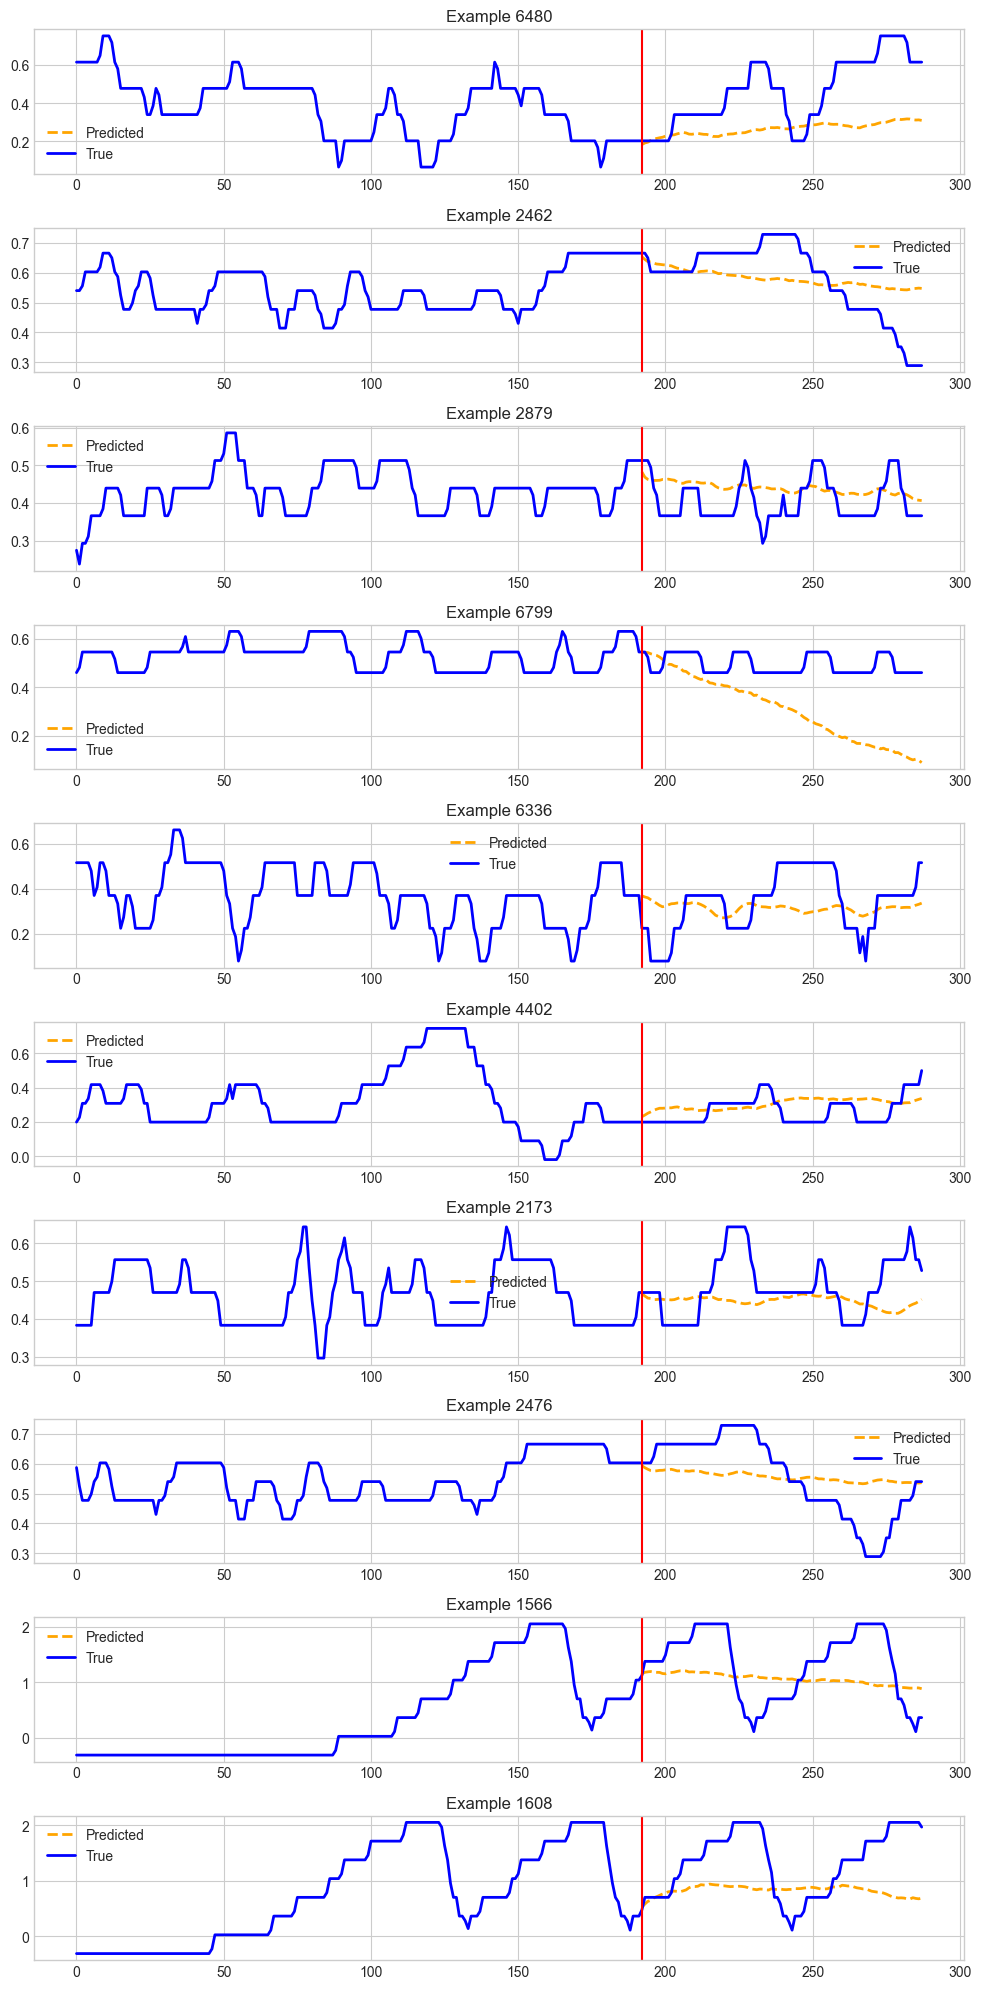

In [13]:
plot_predictions(
    model=zeroshot_trainer.model,
    dset=test_dataset,
    plot_prefix="test_zeroshot",
    channel=0,
)

In [14]:
finetune_forecast_model = get_model(
    TTM_MODEL_PATH,
    context_length=context_length,
    prediction_length=forecast_length,
    num_input_channels=tsp.num_input_channels,
    decoder_mode="mix_channel",
    prediction_channel_indices=tsp.prediction_channel_indices,
)

for param in finetune_forecast_model.backbone.parameters():
    param.requires_grad = False

INFO:p-73504:t-8534990592:get_model.py:get_model:Loading model from: ibm-granite/granite-timeseries-ttm-r2
Some weights of TinyTimeMixerForPrediction were not initialized from the model checkpoint at ibm-granite/granite-timeseries-ttm-r2 and are newly initialized: ['decoder.decoder_block.mixers.0.channel_feature_mixer.gating_block.attn_layer.bias', 'decoder.decoder_block.mixers.0.channel_feature_mixer.gating_block.attn_layer.weight', 'decoder.decoder_block.mixers.0.channel_feature_mixer.mlp.fc1.bias', 'decoder.decoder_block.mixers.0.channel_feature_mixer.mlp.fc1.weight', 'decoder.decoder_block.mixers.0.channel_feature_mixer.mlp.fc2.bias', 'decoder.decoder_block.mixers.0.channel_feature_mixer.mlp.fc2.weight', 'decoder.decoder_block.mixers.0.channel_feature_mixer.norm.norm.bias', 'decoder.decoder_block.mixers.0.channel_feature_mixer.norm.norm.weight', 'decoder.decoder_block.mixers.1.channel_feature_mixer.gating_block.attn_layer.bias', 'decoder.decoder_block.mixers.1.channel_feature_mixer

In [15]:
num_epochs = 100
batch_size = 64

learning_rate, finetune_forecast_model = optimal_lr_finder(
    finetune_forecast_model,
    train_dataset,
    batch_size=batch_size,
    device=device,
    enable_prefix_tuning=False,
)
print("OPTIMAL SUGGESTED LEARNING RATE =", learning_rate)

INFO:p-73504:t-8534990592:lr_finder.py:optimal_lr_finder:LR Finder: Running learning rate (LR) finder algorithm. If the suggested LR is very low, we suggest setting the LR manually.
INFO:p-73504:t-8534990592:lr_finder.py:optimal_lr_finder:LR Finder: Using CPU.
INFO:p-73504:t-8534990592:lr_finder.py:optimal_lr_finder:LR Finder: Suggested learning rate = 0.000756463327554629


OPTIMAL SUGGESTED LEARNING RATE = 0.000756463327554629


In [16]:
print(f"Using learning rate = {learning_rate}")
finetune_forecast_args = TrainingArguments(
    output_dir=os.path.join(OUT_DIR, "output"),
    overwrite_output_dir=True,
    learning_rate=learning_rate,
    num_train_epochs=num_epochs,
    do_eval=True,
    eval_strategy="epoch",
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    dataloader_num_workers=8,
    report_to=None,
    save_strategy="epoch",
    logging_strategy="epoch",
    save_total_limit=1,
    logging_dir=os.path.join(OUT_DIR, "logs"),  # Make sure to specify a logging directory
    load_best_model_at_end=True,  # Load the best model when training ends
    metric_for_best_model="eval_loss",  # Metric to monitor for early stopping
    greater_is_better=False,  # For loss
)

# Create the early stopping callback
early_stopping_callback = EarlyStoppingCallback(
    early_stopping_patience=10,  # Number of epochs with no improvement after which to stop
    early_stopping_threshold=0.0,  # Minimum improvement required to consider as improvement
)
tracking_callback = TrackingCallback()

# Optimizer and scheduler
optimizer = AdamW(finetune_forecast_model.parameters(), lr=learning_rate)
scheduler = OneCycleLR(
    optimizer,
    learning_rate,
    epochs=num_epochs,
    steps_per_epoch=math.ceil(len(train_dataset) / (batch_size)),
)

finetune_forecast_trainer = Trainer(
    model=finetune_forecast_model,
    args=finetune_forecast_args,
    train_dataset=train_dataset,
    eval_dataset=valid_dataset,
    callbacks=[early_stopping_callback, tracking_callback],
    optimizers=(optimizer, scheduler),
)

# Fine tune
finetune_forecast_trainer.train()

/Users/darenpalmer/Desktop/UCL/CS/fyp.nosync/.venv/lib/python3.10/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Using learning rate = 0.000756463327554629


Epoch,Training Loss,Validation Loss
1,0.248600,0.328288
2,0.217900,0.327601
3,0.205300,0.329057
4,0.195200,0.331719
5,0.187700,0.327797
6,0.182800,0.325527
7,0.176600,0.319960
8,0.171700,0.317058
9,0.166300,0.319502
10,0.160700,0.315357


/Users/darenpalmer/Desktop/UCL/CS/fyp.nosync/.venv/lib/python3.10/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/darenpalmer/Desktop/UCL/CS/fyp.nosync/.venv/lib/python3.10/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/darenpalmer/Desktop/UCL/CS/fyp.nosync/.venv/lib/python3.10/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/darenpalmer/Desktop/UCL/CS/fyp.nosync/.venv/lib/python3.10/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pin

[TrackingCallback] Mean Epoch Time = 156.37343683387294 seconds, Total Train Time = 7515.561272144318


TrainOutput(global_step=3861, training_loss=0.1443872039289062, metrics={'train_runtime': 7515.5612, 'train_samples_per_second': 99.181, 'train_steps_per_second': 1.557, 'total_flos': 1.4099887607427072e+16, 'train_loss': 0.1443872039289062, 'epoch': 33.0})

In [17]:
finetune_forecast_trainer.evaluate(test_dataset)

/Users/darenpalmer/Desktop/UCL/CS/fyp.nosync/.venv/lib/python3.10/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


{'eval_loss': 0.18172062933444977,
 'eval_runtime': 100.6997,
 'eval_samples_per_second': 69.762,
 'eval_steps_per_second': 1.092,
 'epoch': 33.0}

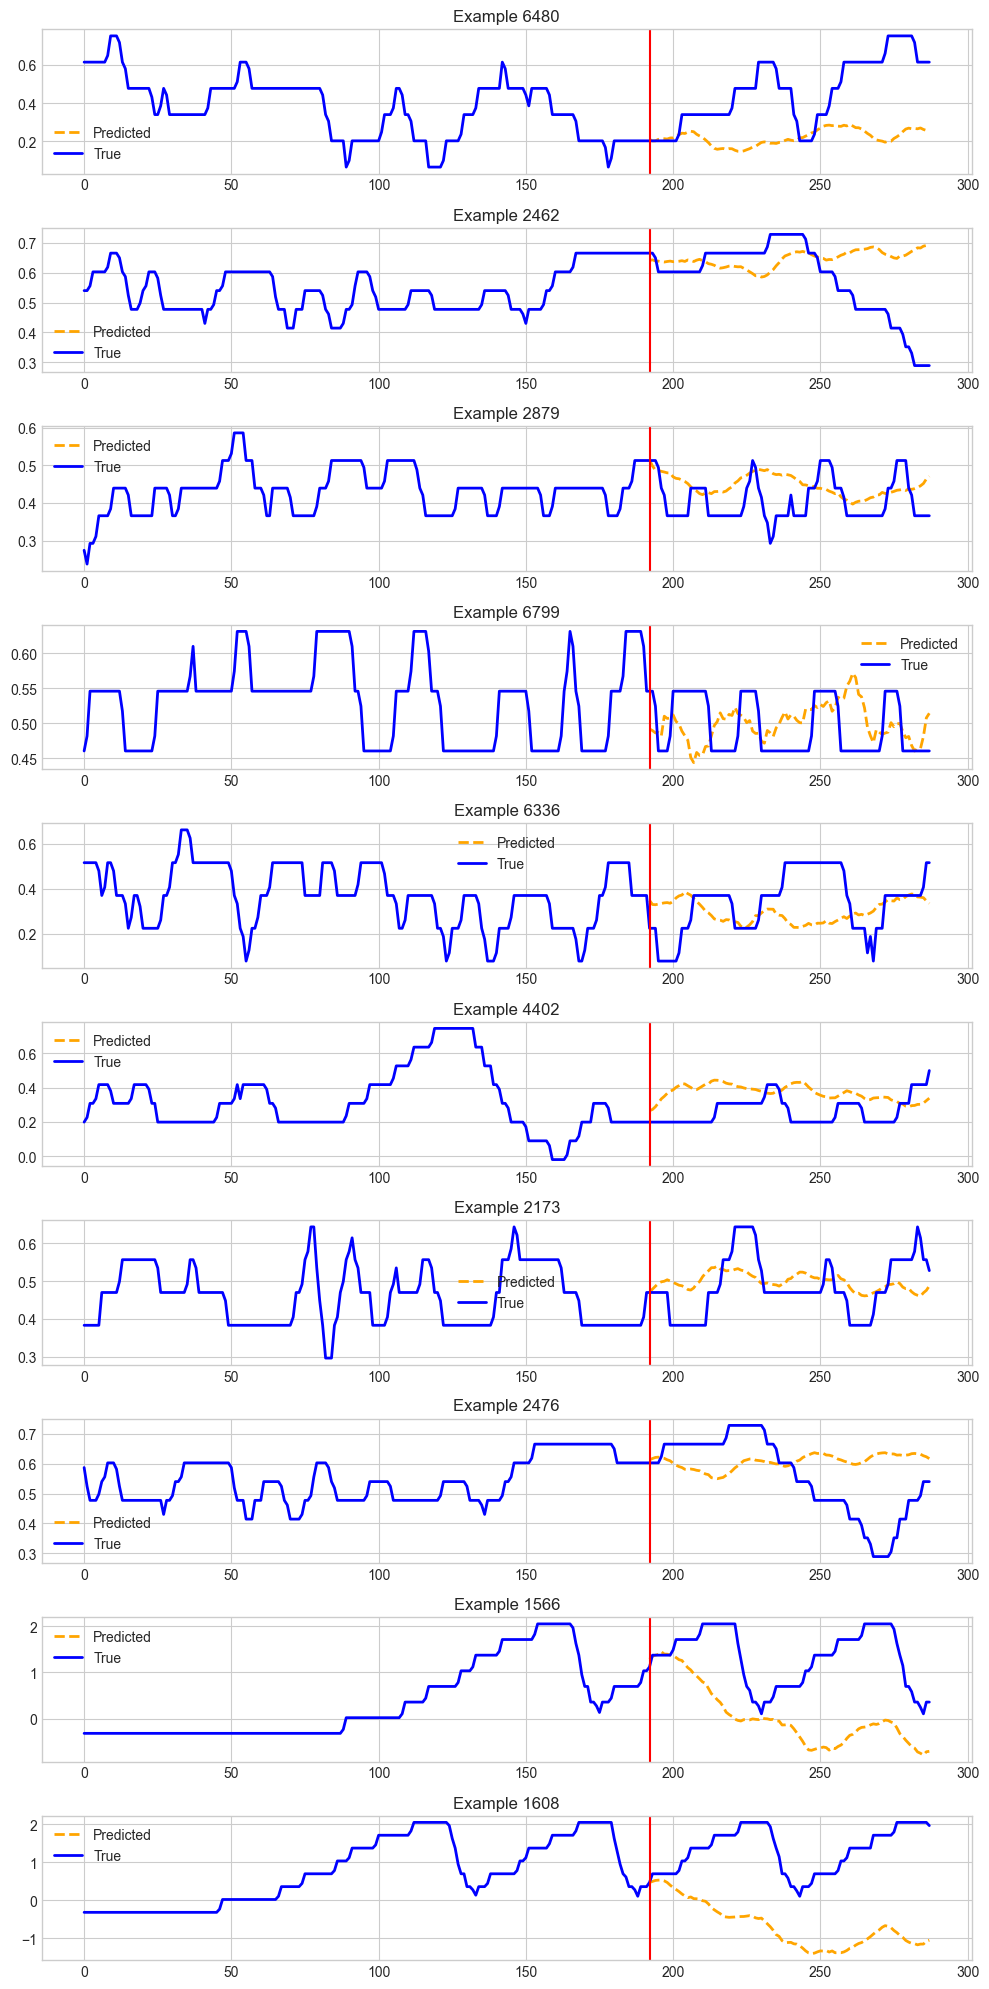

In [18]:
plot_predictions(
    model=finetune_forecast_trainer.model,
    dset=test_dataset,
    plot_prefix="test_finetune",
    channel=0,
)